<a href="https://colab.research.google.com/github/Abhi757575/GEN-N-Review-/blob/main/CandD_by_sid.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install kaggle

In [ ]:
# configuring the path of Kaggle.json file
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
# Kaggle api
!kaggle competitions download -c dogs-vs-cats

100% 812M/812M [00:05<00:00, 153MB/s]



In [ ]:
!ls


dogs-vs-cats.zip  kaggle.json  sample_data


In [ ]:
#extracting the compressed dataset
from zipfile import ZipFile

dataset = '/content/dogs-vs-cats.zip'

with ZipFile(dataset, 'r') as zip:
  zip.extractall()
  print('The dataset is extracted')

The dataset is extracted


In [ ]:
#extracting the compressed train zip
dataset='/content/train.zip'

with ZipFile(dataset, 'r') as zip:
  zip.extractall()
  print("The dataset is extracted")

The dataset is extracted


In [ ]:
import os
# counting the number of file in dataset

train_dir = '/content/train'

if not os.path.exists(train_dir):
  print(f"Error: The directory '{train_dir}' does not exist. This usually happens if 'train.zip' was not extracted correctly. Please check previous steps (e.g., cell MuwKs9vl700c) for extraction issues.")
  file_count = 0
  print(file_count)
else:
  try:
    # os.walk yields a 3-tuple (dirpath, dirnames, filenames).
    # We want to count files in the top-level 'train' directory.
    path, dirs, files = next(os.walk(train_dir))
    file_count = len(files)
    print(file_count)
  except StopIteration:
    print(f"Warning: Directory '{train_dir}' exists but appears to be empty or not properly structured for os.walk at the top level.")
    file_count = 0 # If StopIteration happens here, it means the directory was empty.
    print(file_count)

25000


In [ ]:
file_names = os.listdir('/content/train/')
print(file_names[:10])

['cat.4368.jpg', 'cat.8376.jpg', 'cat.9717.jpg', 'cat.10529.jpg', 'cat.9270.jpg', 'cat.3468.jpg', 'cat.9142.jpg', 'dog.10416.jpg', 'dog.7239.jpg', 'dog.10147.jpg']


Importing Dependencies

In [ ]:
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from google.colab.patches import cv2_imshow


Display the images

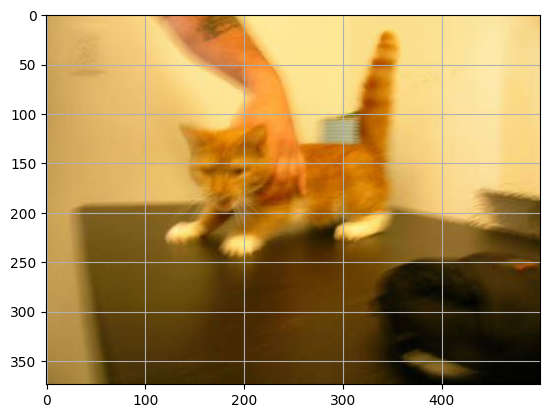

In [ ]:
img = mpimg.imread('/content/train/cat.0.jpg')
imgplt = plt.imshow(img)
plt.grid(True)
plt.show()

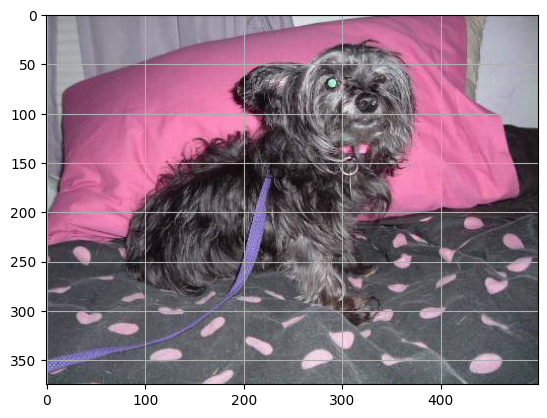

In [ ]:
imgread = mpimg.imread('/content/train/dog.0.jpg')
imgplt = plt.imshow(imgread)
plt.grid(True)
plt.show()

In [ ]:
file_names = os.listdir('/content/train/')

for i in range(len(file_names)):
  name = file_names[i]
  print(name[0:3])

cat
cat
cat
cat
cat
cat
cat
dog
dog
dog
cat
dog
dog
dog
cat
dog
cat
cat
cat
cat
dog
cat
dog
dog
cat
dog
dog
cat
dog
dog
dog
dog
cat
dog
dog
cat
dog
cat
cat
dog
cat
cat
dog
cat
dog
dog
dog
dog
cat
cat
dog
cat
cat
dog
dog
cat
cat
dog
dog
cat
dog
cat
dog
dog
cat
cat
cat
dog
dog
dog
cat
cat
cat
dog
cat
dog
cat
dog
cat
cat
cat
cat
dog
cat
cat
dog
cat
dog
cat
cat
cat
cat
cat
dog
cat
dog
dog
dog
cat
dog
dog
dog
dog
dog
dog
dog
dog
cat
cat
dog
dog
dog
dog
dog
cat
cat
dog
cat
cat
cat
dog
cat
dog
cat
cat
dog
dog
dog
dog
cat
cat
cat
dog
dog
cat
cat
dog
cat
cat
dog
cat
cat
cat
dog
cat
dog
cat
dog
dog
dog
dog
cat
cat
cat
dog
dog
cat
cat
dog
cat
dog
cat
cat
dog
dog
cat
dog
cat
dog
cat
dog
dog
cat
dog
dog
cat
dog
dog
cat
cat
cat
dog
dog
dog
cat
dog
cat
cat
cat
dog
cat
dog
cat
cat
dog
cat
dog
cat
cat
dog
cat
dog
dog
dog
cat
dog
dog
cat
cat
dog
cat
cat
dog
dog
cat
dog
dog
dog
dog
dog
cat
dog
dog
cat
cat
dog
dog
cat
cat
cat
cat
cat
dog
dog
dog
dog
dog
cat
cat
cat
dog
dog
cat
cat
cat
dog
cat
cat
cat
cat


In [ ]:
file_names = os.listdir('/content/train/')
dog_count = 0
cat_count = 0

for img_file in file_names:
  name = img_file[:3] # Corrected: get first 3 chars of the current filename

  if name == 'dog':
    dog_count+=1
  elif name == 'cat': # Changed to elif for better logic
    cat_count+=1
  # No else needed if we only expect 'dog' or 'cat' prefixes
  # If there could be other prefixes, we might want to log them instead of 'error'

print(f"Dog count: {dog_count}")
print(f"Cat count: {cat_count}")

Dog count: 12500
Cat count: 12500


Resizing Images

In [ ]:
#creating a directory for resized images

os.mkdir('/content/image_resized')

In [ ]:
original_folder =  '/content/train/'
resized_folder = '/content/image_resized/'

for i in range(2000):
  filename = os.listdir(original_folder)[i]
  img_path = original_folder+filename

  img = Image.open(img_path)
  img = img.resize((224, 224))
  img = img.convert('RGB')

  new_img_path = resized_folder+filename
  img.save(new_img_path)

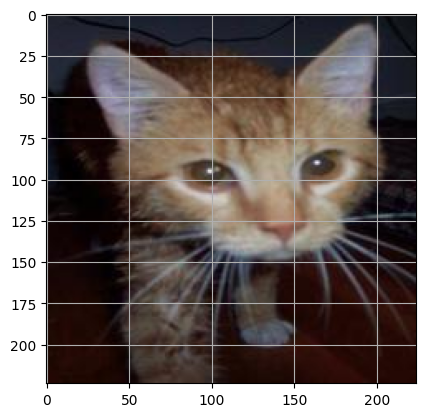

In [ ]:
#display resized image
img = plt.imread('/content/image_resized/cat.10039.jpg')
imgplt = plt.imshow(img)
plt.grid(True)
plt.show()

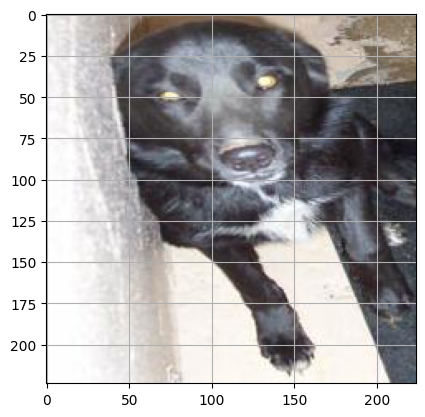

In [ ]:
#display resized image
img = plt.imread('/content/image_resized/dog.10000.jpg')
imgplt = plt.imshow(img)
plt.grid(True)
plt.show()

Introducing labels
cat -->0
dof -->1

In [ ]:
#creating a for loop

labels = []
filenames = os.listdir('/content/image_resized/')

for i in range(2000):

  file_name = filenames[i]
  label = file_name[:3]

  if label == 'cat':
    labels.append(0)
  elif label == 'dog':
    labels.append(1)


In [ ]:
print(filenames[0:5])
print(len(filenames))

['cat.4368.jpg', 'cat.8376.jpg', 'cat.9717.jpg', 'cat.10529.jpg', 'cat.9270.jpg']
2000


In [ ]:
print(labels[0:5])
print(len(labels))

[0, 0, 0, 0, 0]
2000


In [ ]:
#counting the images of dogs and cats out of 2000 images

values , counts = np.unique(labels, return_counts=True)
print(values)
print(counts)

[0 1]
[ 990 1010]


**Converting all the Resized images to numpy arrays**

In [ ]:
import cv2
import glob

In [ ]:
image_directory = '/content/image_resized/'
image_extension = ['png ', 'jpg']

files = []

[files.extend(glob.glob(image_directory + '*.' + e)) for e in image_extension]

dog_cat_images = np.asarray([cv2.imread(file) for file in files])

In [ ]:
print(dog_cat_images)

[[[[248 250 250]
   [253 255 255]
   [253 255 255]
   ...
   [255 254 251]
   [255 255 252]
   [255 255 252]]

  [[253 255 255]
   [253 255 255]
   [251 253 253]
   ...
   [255 254 251]
   [255 252 249]
   [255 253 250]]

  [[253 255 254]
   [251 254 252]
   [250 253 251]
   ...
   [255 253 252]
   [254 250 249]
   [255 255 254]]

  ...

  [[255 250 252]
   [253 250 252]
   [254 252 252]
   ...
   [255 255 255]
   [255 253 255]
   [254 249 251]]

  [[255 255 247]
   [255 255 245]
   [255 253 245]
   ...
   [255 254 255]
   [255 251 253]
   [251 246 248]]

  [[255 255 244]
   [255 255 243]
   [255 255 244]
   ...
   [255 254 255]
   [255 254 255]
   [255 254 255]]]


 [[[ 48  44  39]
   [108 104  99]
   [117 114 109]
   ...
   [217 220 218]
   [216 221 219]
   [206 211 209]]

  [[ 58  54  49]
   [106 102  97]
   [118 115 110]
   ...
   [214 217 215]
   [215 218 216]
   [215 218 216]]

  [[ 79  77  69]
   [106 104  96]
   [123 120 115]
   ...
   [215 213 212]
   [216 214 213]
   [220 221

In [ ]:
print(dog_cat_images.shape)

(2000, 224, 224, 3)


In [ ]:
X = dog_cat_images
Y = np.asarray(labels)

Train Test Split

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)


In [ ]:
print(X.shape, X_train.shape, X_test.shape)

(2000, 224, 224, 3) (1600, 224, 224, 3) (400, 224, 224, 3)


1600 -> train
400  -> test

In [ ]:
#scaling the data
X_train_scaled = X_train/255

X_test_scaled = X_test/255


In [ ]:
print(X_train_scaled)
print(X_test_scaled)

[[[[0.76862745 0.79607843 0.76862745]
   [0.72941176 0.75686275 0.72941176]
   [0.68235294 0.69803922 0.6745098 ]
   ...
   [0.63529412 0.64705882 0.67843137]
   [0.64313725 0.65098039 0.68235294]
   [0.62745098 0.63529412 0.66666667]]

  [[0.76078431 0.78823529 0.76078431]
   [0.64313725 0.67058824 0.64313725]
   [0.6        0.61568627 0.59215686]
   ...
   [0.49803922 0.50980392 0.54117647]
   [0.50196078 0.50980392 0.54117647]
   [0.49019608 0.49803922 0.52941176]]

  [[0.71372549 0.7372549  0.71764706]
   [0.53333333 0.55686275 0.5372549 ]
   [0.54509804 0.56078431 0.54117647]
   ...
   [0.45490196 0.47843137 0.50588235]
   [0.45490196 0.46666667 0.49803922]
   [0.44313725 0.45490196 0.48627451]]

  ...

  [[0.55686275 0.6        0.63137255]
   [0.36862745 0.41176471 0.44313725]
   [0.42352941 0.46666667 0.49803922]
   ...
   [0.29803922 0.36078431 0.40784314]
   [0.32156863 0.38431373 0.43137255]
   [0.34509804 0.40784314 0.45490196]]

  [[0.54117647 0.58431373 0.61568627]
   [0.3

Building NN

In [ ]:
import tensorflow as tf
import tensorflow_hub as hub

In [ ]:
!pip install tf_keras
import tf_keras

In [ ]:
mobilenet_model = 'https://tfhub.dev/google/tf2-preview/mobilenet_v2/feature_vector/4'

pretrained_model = hub.KerasLayer(mobilenet_model, input_shape=(224,224,3), trainable=False)

In [ ]:
num_of_classes = 2

model = tf_keras.Sequential([

    pretrained_model,
    tf_keras.layers.Dense(num_of_classes)

])

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 keras_layer_2 (KerasLayer)  (None, 1280)              2257984   
                                                                 
 dense (Dense)               (None, 2)                 2562      
                                                                 
Total params: 2260546 (8.62 MB)
Trainable params: 2562 (10.01 KB)
Non-trainable params: 2257984 (8.61 MB)
_________________________________________________________________


In [ ]:
model.compile(
    optimizer = 'adam',
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics = ['acc']
)

In [ ]:
model.fit(X_train_scaled, Y_train, epochs=5)

Epoch 1/5
50/50 [==============================] - 110s 2s/step - loss: 0.1795 - acc: 0.9237
Epoch 2/5
50/50 [==============================] - 86s 2s/step - loss: 0.0671 - acc: 0.9775
Epoch 3/5
50/50 [==============================] - 79s 2s/step - loss: 0.0488 - acc: 0.9856
Epoch 4/5
50/50 [==============================] - 83s 2s/step - loss: 0.0376 - acc: 0.9900
Epoch 5/5
50/50 [==============================] - 61s 1s/step - loss: 0.0328 - acc: 0.9906


In [ ]:
score, acc = model.evaluate(X_test_scaled, Y_test)
print('Test Loss', score)
print('Test Accuracy', acc)

13/13 [==============================] - 16s 1s/step - loss: 0.0757 - acc: 0.9750
Test Loss 0.07568298280239105
Test Accuracy 0.9750000238418579


Predictive System

Path of the image to be predicted: /content/sbhsb.jpg


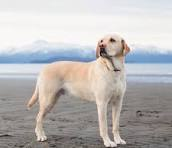

1/1 [==============================] - 0s 58ms/step
[[-2.9294398  3.9990869]]
1
The image represents a Dog


In [ ]:
input_image_path = input('Path of the image to be predicted: ')

input_image = cv2.imread(input_image_path)

cv2_imshow(input_image)

input_image_resize = cv2.resize(input_image, (224,224))

input_image_scaled = input_image_resize/255

image_reshaped = np.reshape(input_image_scaled, [1,224,224,3])

input_prediction = model.predict(image_reshaped)

print(input_prediction)

input_pred_label = np.argmax(input_prediction)

print(input_pred_label)

if input_pred_label == 0:
  print('The image represents a Cat')

else:
  print('The image represents a Dog')

In [ ]:
Vanilla

In [54]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D
from keras.layers import Dropout, Flatten, Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [55]:
model = Sequential()
model.add(Conv2D(32, (3,3), input_shape=(224,224,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(units = 128, activation = 'relu'))
model.add(Dropout(0.5))
model.add(Dense(units = 1, activation = 'sigmoid'))




/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [56]:
model.compile(optimizer = 'adam', loss = 'binary_crossentropy',
              metrics = ['accuracy'])

In [ ]:
model.fit(X_train_scaled, Y_train, epochs=5, verbose=1)

Epoch 1/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 151s 3s/step - accuracy: 0.5050 - loss: 1.8385
Epoch 2/5
22/50 ━━━━━━━━━━━━━━━━━━━━ 1:19 3s/step - accuracy: 0.5972 - loss: 0.6838